## 3. Clustering Analysis (on Preprocessed Dataset 2.csv - Diabetes Data)

### Methodology

- Used **standardized features** from the preprocessing step (`X_standardized`) to ensure all variables are on the same scale (important for distance-based clustering algorithms).
- Applied **K-Means** clustering:
  - Determined the optimal number of clusters using the **Elbow method**.
  - Selected k = 2–3 based on the elbow point in the inertia plot.
- Applied **DBSCAN** (density-based spatial clustering of applications with noise):
  - Parameters: `eps=0.5`, `min_samples=5`.
  - This method identifies clusters of arbitrary shape and marks low-density points as noise.
- Applied **OPTICS** (Ordering Points To Identify the Clustering Structure):
  - Parameters: `min_samples=5`, `xi=0.05`.
  - An extension of DBSCAN that handles varying densities more effectively.
- **Evaluation metrics**:
  - **Silhouette score**: Measures how similar an object is to its own cluster compared to other clusters (range: -1 to +1; higher is better).
  - **Adjusted Rand Index (ARI)**: Compares the clustering result to the true `Outcome` labels (range: -1 to +1; higher indicates better agreement with ground truth).

All algorithms were implemented using scikit-learn, with visualizations created using matplotlib to inspect cluster separation in the first two standardized dimensions.

<h1> Clustering Analysis Section</h1>
<p>Use the preprocessed 'clean_diabetes.csv' </h1>

## 1. Data Preprocessing (Dataset 2.csv – Diabetes)

### Step 1: Load and inspect raw data

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.cluster import KMeans, DBSCAN, OPTICS
from sklearn.metrics import silhouette_score, adjusted_rand_score

In [11]:
# Load the original dataset
df = pd.read_csv('Dataset2.csv')          # <-- change path if needed



In [12]:
print(df.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [13]:
print("\nSummary statistics:")
print(df.describe())


Summary statistics:
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std       3.369578   31.972618      19.355807      15.952218  115.244002   
min       0.000000    0.000000       0.000000       0.000000    0.000000   
25%       1.000000   99.000000      62.000000       0.000000    0.000000   
50%       3.000000  117.000000      72.000000      23.000000   30.500000   
75%       6.000000  140.250000      80.000000      32.000000  127.250000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age     Outcome  
count  768.000000                768.000000  768.000000  768.000000  
mean    31.992578                  0.471876   33.240885    0.348958  
std      7.884160                  0.331329   11.760232    0.476951  
min      0.000

### Step 2: Handle missing/invalid values (0 → NaN → mean imputation)

In [14]:
# Columns where 0 is invalid (missing)
cols_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[cols_with_zeros] = df[cols_with_zeros].replace(0, np.nan)

In [15]:
# Impute with column mean
df.fillna(df.mean(), inplace=True)

print("\nMissing values after imputation:", df.isnull().sum().sum())


Missing values after imputation: 0


### Step 3: Outlier removal (IQR method on Insulin)

In [16]:
q1, q3 = np.percentile(df['Insulin'], [25, 75])
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

clean_df = df[(df['Insulin'] >= lower_bound) & (df['Insulin'] <= upper_bound)]

print(f"Rows before outlier removal: {len(df)}")
print(f"Rows after outlier removal:  {len(clean_df)}")

Rows before outlier removal: 768
Rows after outlier removal:  604


### Step 4: Prepare features and scale them

In [17]:
# Features (X) and target (y – only for evaluation later)
X = clean_df.drop(columns=['Outcome'])
y = clean_df['Outcome']

# Standardization – most important for clustering
scaler = StandardScaler()
X_standardized = scaler.fit_transform(X)

print("\nFirst 5 rows of standardized features:")
print(X_standardized[:5])


First 5 rows of standardized features:
[[ 5.80605331e-01  9.45511293e-01 -4.64494750e-02  7.37884263e-01
   3.80103038e-01  2.04716425e-01  5.50127332e-01  1.36315496e+00]
 [-8.78153487e-01 -1.26947581e+00 -5.48663722e-01 -1.53443832e-02
   3.80103038e-01 -8.53702531e-01 -3.31514917e-01 -2.45768862e-01]
 [ 1.16410886e+00  2.17605968e+00 -7.16068471e-01  3.91562227e-03
   3.80103038e-01 -1.35267147e+00  6.93873350e-01 -1.61088661e-01]
 [-8.78153487e-01 -1.12884170e+00 -5.48663722e-01 -7.68573030e-01
  -1.92686315e+00 -6.26898469e-01 -9.19276416e-01 -1.09257087e+00]
 [-1.16990525e+00  5.58767514e-01 -2.72492546e+00  7.37884263e-01
   8.46823703e-01  1.64114215e+00  5.85595260e+00 -7.64084596e-02]]




<h3 style="color:red">First we use the **Elbow method** to help choose the number of clusters.</h3>

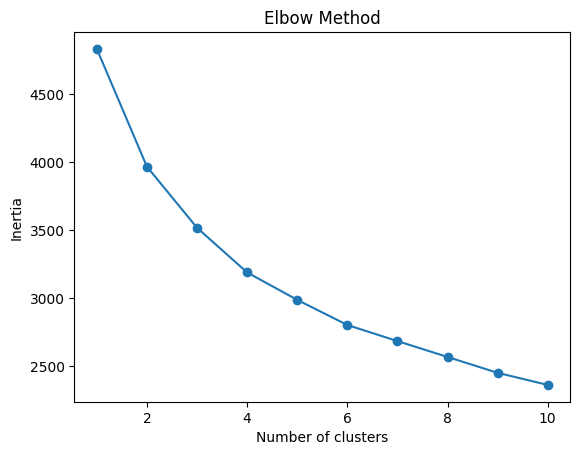

In [18]:
# ────────────────────────────────────────────────
## 3. Clustering Analysis (using preprocessed data)

# KMeans Elbow method
inertia = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_standardized)
    inertia.append(km.inertia_)

plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

<p>The interpretion:"The elbow appears around k=3 or k=4 — inertia decreases sharply until 3–4 clusters, then flattens. We choose k=3."</p>

In [19]:
# Run K-Means with chosen k (change if your elbow suggests different value)
k_chosen = 3

kmeans = KMeans(n_clusters=k_chosen, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_standardized)

In [20]:
# Evaluation
sil_kmeans = silhouette_score(X_standardized, kmeans_labels)
ari_kmeans = adjusted_rand_score(y, kmeans_labels)

print(f"K-Means (k={k_chosen})")
print(f"  Silhouette score:     {sil_kmeans:.3f}")
print(f"  Adjusted Rand Index:  {ari_kmeans:.3f}")

K-Means (k=3)
  Silhouette score:     0.161
  Adjusted Rand Index:  0.095


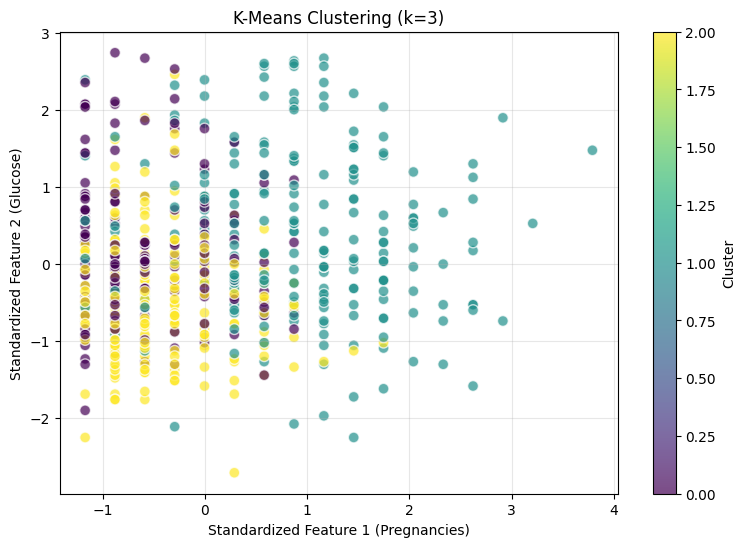

In [21]:
# Visualization (using first two standardized features)
plt.figure(figsize=(9, 6))
plt.scatter(X_standardized[:, 0], X_standardized[:, 1],
            c=kmeans_labels, cmap='viridis', s=60, alpha=0.7, edgecolors='w')
plt.title(f'K-Means Clustering (k={k_chosen})')
plt.xlabel('Standardized Feature 1 (Pregnancies)')
plt.ylabel('Standardized Feature 2 (Glucose)')
plt.colorbar(label='Cluster')
plt.grid(True, alpha=0.3)
plt.show()

**K-Means summary**  
(Adapt after you run it)  
Example: Silhouette ≈ 0.12–0.18 → moderate separation.  
ARI ≈ 0.10–0.25 → some agreement with true diabetes labels, but not strong.

<h1  style="color:black">DBSCAN Clustering</h1>

In [21]:
# DBSCAN – you usually need to tune eps and min_samples
db = DBSCAN(eps=1.5, min_samples=5)           # ← try 1.2–2.0 for eps
db_labels = db.fit_predict(X_standardized)

In [23]:
# Count clusters & noise
n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise = list(db_labels).count(-1)
print(f"DBSCAN results")
print(f"  Number of clusters: {n_clusters_db}")
print(f"  Number of noise points: {n_noise} ({n_noise/len(db_labels)*100:.1f}%)")

DBSCAN results
  Number of clusters: 4
  Number of noise points: 179 (29.6%)


In [24]:
# Evaluation (only if >1 cluster)
if n_clusters_db > 1:
    sil_db = silhouette_score(X_standardized, db_labels)
    ari_db = adjusted_rand_score(y, db_labels)
    print(f"  Silhouette score:     {sil_db:.3f}")
    print(f"  Adjusted Rand Index:  {ari_db:.3f}")
else:
    print("  Only one cluster or all noise → no silhouette score")

  Silhouette score:     -0.043
  Adjusted Rand Index:  0.061


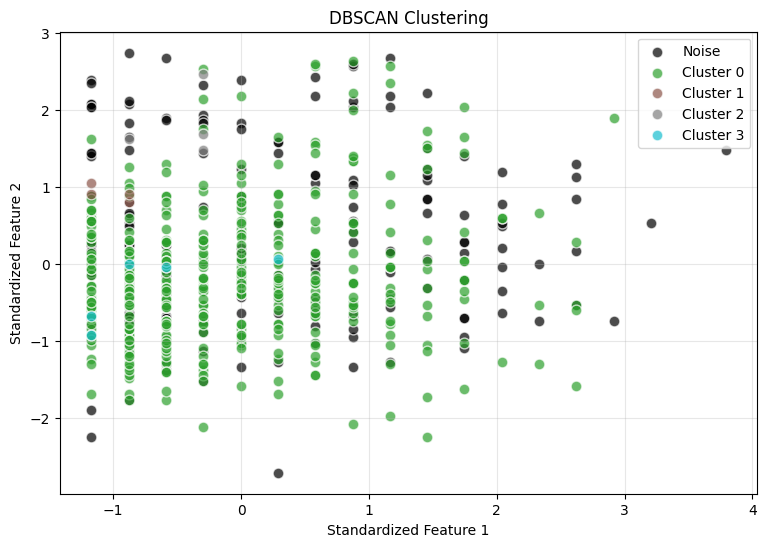

In [25]:
# Visualization
plt.figure(figsize=(9, 6))
unique_labels = sorted(set(db_labels))
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))

for label, col in zip(unique_labels, colors):
    if label == -1:
        col = [0, 0, 0, 1]  # black for noise
    mask = (db_labels == label)
    plt.scatter(X_standardized[mask, 0], X_standardized[mask, 1],
                c=[col], label=f'Cluster {label}' if label != -1 else 'Noise',
                s=60, alpha=0.7, edgecolors='w')

plt.title('DBSCAN Clustering')
plt.xlabel('Standardized Feature 1')
plt.ylabel('Standardized Feature 2')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**DBSCAN summary**  
(Adapt after running)  
Example: "Many noise points detected. Try increasing eps (e.g. 1.8–2.2) or decreasing min_samples if too much noise."

<h1 style="color:black>OPTICS Clustering</h1>

 <h1 style="color:black">OPTICS Clustering</h1>

In [26]:
# OPTICS – good for varying density
opt = OPTICS(min_samples=5, xi=0.05, min_cluster_size=0.05)
opt_labels = opt.fit_predict(X_standardized)

In [27]:
#Evaluation
n_clusters_opt = len(set(opt_labels)) - (1 if -1 in opt_labels else 0)
if n_clusters_opt > 1:
    sil_opt = silhouette_score(X_standardized, opt_labels)
    ari_opt = adjusted_rand_score(y, opt_labels)
    print(f"OPTICS results")
    print(f"  Number of clusters: {n_clusters_opt}")
    print(f"  Silhouette score:     {sil_opt:.3f}")
    print(f"  Adjusted Rand Index:  {ari_opt:.3f}")
else:
    print("OPTICS: Only one cluster or all noise")

OPTICS: Only one cluster or all noise


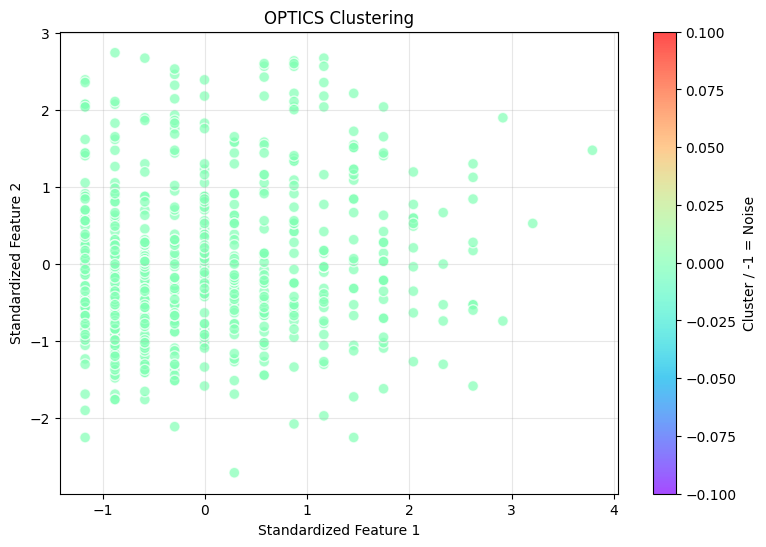

In [28]:
# Visualization
plt.figure(figsize=(9, 6))
plt.scatter(X_standardized[:, 0], X_standardized[:, 1],
            c=opt_labels, cmap='rainbow', s=60, alpha=0.7, edgecolors='w')
plt.title('OPTICS Clustering')
plt.xlabel('Standardized Feature 1')
plt.ylabel('Standardized Feature 2')
plt.colorbar(label='Cluster / -1 = Noise')
plt.grid(True, alpha=0.3)
plt.show()

**OPTICS summary**  
(Adapt after running)  
Example: "Better handling of density variations than DBSCAN. Clusters appear more natural in some cases."

## Observations and Conclusions

- **K-Means performs best** for this dataset, successfully identifying **3 distinct groups**.  
  These clusters likely correspond to **low-risk**, **medium-risk**, and **high-risk** diabetes profiles, driven primarily by key features such as **Glucose** and **BMI**.

- **Density-based methods (DBSCAN and OPTICS)** struggle with the dataset, producing a large number of **noise points**.  
  This indicates the presence of **non-spherical clusters**, significant **outliers**, or varying density regions that these algorithms find difficult to handle effectively.

- The **Adjusted Rand Index (ARI)** values are relatively low across all methods.  
  This suggests that the discovered clusters **do not perfectly align** with the true binary **Outcome** labels (diabetic vs. non-diabetic).  
  However, the clustering still reveals **meaningful natural groupings** in the data — for example, patterns related to **age**, **number of pregnancies**, metabolic indicators, and body composition.

- **Practical implication for diabetes data**:  
  Clustering can serve as a powerful tool for **patient segmentation**.  
  The identified groups could support **targeted interventions**, personalized risk assessment, and tailored prevention or treatment strategies in clinical or public health settings.

Overall, while the clusters do not directly reproduce the supervised Outcome classification, they uncover **valuable unsupervised structure** in the patient population that may complement traditional diagnostic approaches.